Emerson Rodrigues Vero filho

Dsta Scientist


#### Definição do Problema ####

O objetivo deste trabalho é desenvolver um modelo de machine learning capaz de identificar automaticamente o tipo de superfície (como carpete, concreto ou madeira) com base em dados de sensores coletados durante o movimento de um robô. Esses sensores registram informações como aceleração, velocidade angular e orientação espacial. A partir desses sinais temporais, o modelo deve aprender padrões característicos de cada tipo de piso e ser capaz de generalizar para prever corretamente superfícies em novos cenários.


## 1 - Exploração (EDA) e pré-processamento dos dados.

In [69]:
import numpy as np
import pandas as pd

In [70]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("X_train_mod.csv")
dataset_anotado = pd.read_csv("y_train_mod.csv")
hold_out_dataset = pd.read_csv("X_test_mod.csv")

print(f"X_train: {dataset.shape}")
print(f"y_train: {dataset_anotado.shape}")
print(f"X_test:  {hold_out_dataset.shape}")

# não altera o dataset original
dataset_limpo = dataset.dropna(subset=["measurement_number"]).reset_index(drop=True)

def organize_timeseries(df, labels=None):
    df = df.dropna(subset=["row_id"]).copy()

    tmp = df["row_id"].str.split("_", n=1, expand=True)
    df["timeseries"] = tmp[0].astype(int)
    df["numerodoregistro"] = tmp[1].astype(int)

    cols = df.columns.tolist()
    cols.remove("timeseries")
    cols.remove("numerodoregistro")

    row_id_idx = cols.index("row_id") + 1
    new_cols = cols[:row_id_idx] + ["timeseries", "numerodoregistro"] + cols[row_id_idx:]

    return df[new_cols]

def add_sensor_magnitudes(df):
    df = df.copy()

    df["angular_velocity_mag"] = np.sqrt(
        df["angular_velocity_X"]**2 +
        df["angular_velocity_Y"]**2 +
        df["angular_velocity_Z"]**2
    )

    df["linear_acceleration_mag"] = np.sqrt(
        df["linear_acceleration_X"]**2 +
        df["linear_acceleration_Y"]**2 +
        df["linear_acceleration_Z"]**2
    )

    cols = list(df.columns)

    def move_after(col_name, after_col):
        cols.remove(col_name)
        idx = cols.index(after_col) + 1
        cols.insert(idx, col_name)

    move_after("angular_velocity_mag", "angular_velocity_Z")
    move_after("linear_acceleration_mag", "linear_acceleration_Z")

    return df[cols]

dataset_organizado = organize_timeseries(dataset_limpo)
dataset_incrementado = add_sensor_magnitudes(dataset_organizado)

# Adicionar labels de surface usando y_train (dataset_anotado)
# (supondo series_id em dataset_anotado coincide com timeseries em dataset_incrementado)
if "series_id" in dataset_anotado.columns and "surface" in dataset_anotado.columns:
    dataset_labels = dataset_anotado.copy()
    dataset_labels["series_id"] = dataset_labels["series_id"].astype(int)
    dataset_incrementado = dataset_incrementado.merge(
        dataset_labels[["series_id", "surface"]],
        left_on="timeseries",
        right_on="series_id",
        how="left"
    )
    dataset_incrementado = dataset_incrementado.drop(columns=["series_id"], errors="ignore")

    # manter apenas registros com surface disponível
    dataset_incrementado = dataset_incrementado.dropna(subset=["surface"]).reset_index(drop=True)

print("Merge de surface efetuado:", "surface" in dataset_incrementado.columns)
print("Surface missing (depois do drop):", dataset_incrementado["surface"].isna().sum())
print("Linhas finais:", len(dataset_incrementado))

X_train: (492556, 13)
y_train: (3810, 3)
X_test:  (493332, 13)
Merge de surface efetuado: True
Surface missing (depois do drop): 0
Linhas finais: 478538


In [71]:
dataset_incrementado

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
0,0_0,0,0,-0.010728,0.002334,-0.773039,-0.638283,-0.111479,-0.105607,0.099988,0.018410,0.005460,0.101815,-0.710255,2.099627,-9.746216,9.995079,0.0,fine_concrete
1,0_1,0,1,0.001013,0.990504,-0.750346,-0.630241,-0.096623,-0.102306,0.050083,0.042082,0.004863,0.065597,0.335449,1.487888,-9.406142,9.529001,0.0,fine_concrete
2,0_2,0,2,-0.007640,1.990773,-0.754367,-0.635299,-0.106324,-0.110166,0.001823,0.043896,-0.006134,0.044360,-0.262025,1.587835,-8.725550,8.872716,0.0,fine_concrete
3,0_3,0,3,-0.001271,2.979143,-0.759495,-0.643595,-0.115643,-0.101742,0.002906,-0.007165,-0.015861,0.017646,0.421174,1.088723,-10.113493,10.180641,0.0,fine_concrete
4,0_4,0,4,0.008142,3.998463,-0.751108,-0.647003,-0.120263,-0.126985,0.016671,0.004646,0.005801,0.018253,-5.134896,1.460306,-10.437720,11.723722,0.0,fine_concrete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478533,2508_42,2508,42,2507.995953,42.008649,0.639785,-0.770531,-0.084695,0.096751,-0.018681,0.020804,0.014637,0.031560,0.509884,2.817206,-9.864607,10.271665,2508.0,soft_pvc
478534,1302_107,1302,107,1301.999524,106.989327,0.710180,-0.678617,-0.097849,0.103516,-0.006049,-0.159544,0.449193,0.476723,0.367407,2.717435,-10.086216,10.452329,1302.0,soft_tiles
478535,2604_90,2604,90,2604.021026,89.984887,0.990277,0.163331,0.036473,0.146333,0.058441,0.077504,-0.082590,0.127449,3.405545,1.492476,-7.036229,7.958250,2604.0,fine_concrete
478536,3058_3,3058,3,3057.989380,2.992674,0.744428,-0.636482,-0.089830,0.109252,0.098373,-0.136005,-0.045364,0.173874,-8.006463,-2.357082,-7.949333,11.526109,3058.0,hard_tiles_large_space


In [72]:
one_data=dataset_incrementado[dataset_incrementado["timeseries"] == 6].head()
one_data

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
753,6_0,6,0,6.010971,0.018717,-4.076611,-0.880869,-0.147429,-0.052177,0.034282,0.024732,-0.030570,0.052167,0.103464,3.294834,-8.353144,8.980070,6.0,soft_pvc
754,6_1,6,1,6.007579,1.002993,-0.404479,-0.903442,-0.123701,-0.049351,0.004848,0.014153,-0.013237,0.019976,1.426662,2.301941,-9.203519,9.593699,6.0,soft_pvc
755,6_2,6,2,5.983460,1.994626,-0.413309,-0.900024,-0.144291,-0.056230,0.008095,0.001457,-0.001592,0.008378,0.148731,1.915393,-10.016802,10.199371,6.0,soft_pvc
756,6_3,6,3,6.003942,3.001110,-0.394299,-0.893923,-0.140963,-0.053484,0.051177,0.002186,-0.020745,0.055265,-0.031363,2.168306,-10.105237,10.335296,6.0,soft_pvc
757,6_4,6,4,6.013617,4.000314,-0.407326,-0.907729,-0.130171,-0.035402,0.056166,0.018763,-0.042168,0.072697,0.611161,2.434669,-9.750459,10.068396,6.0,soft_pvc


Visualizacao dos Dados para uma serie temporal

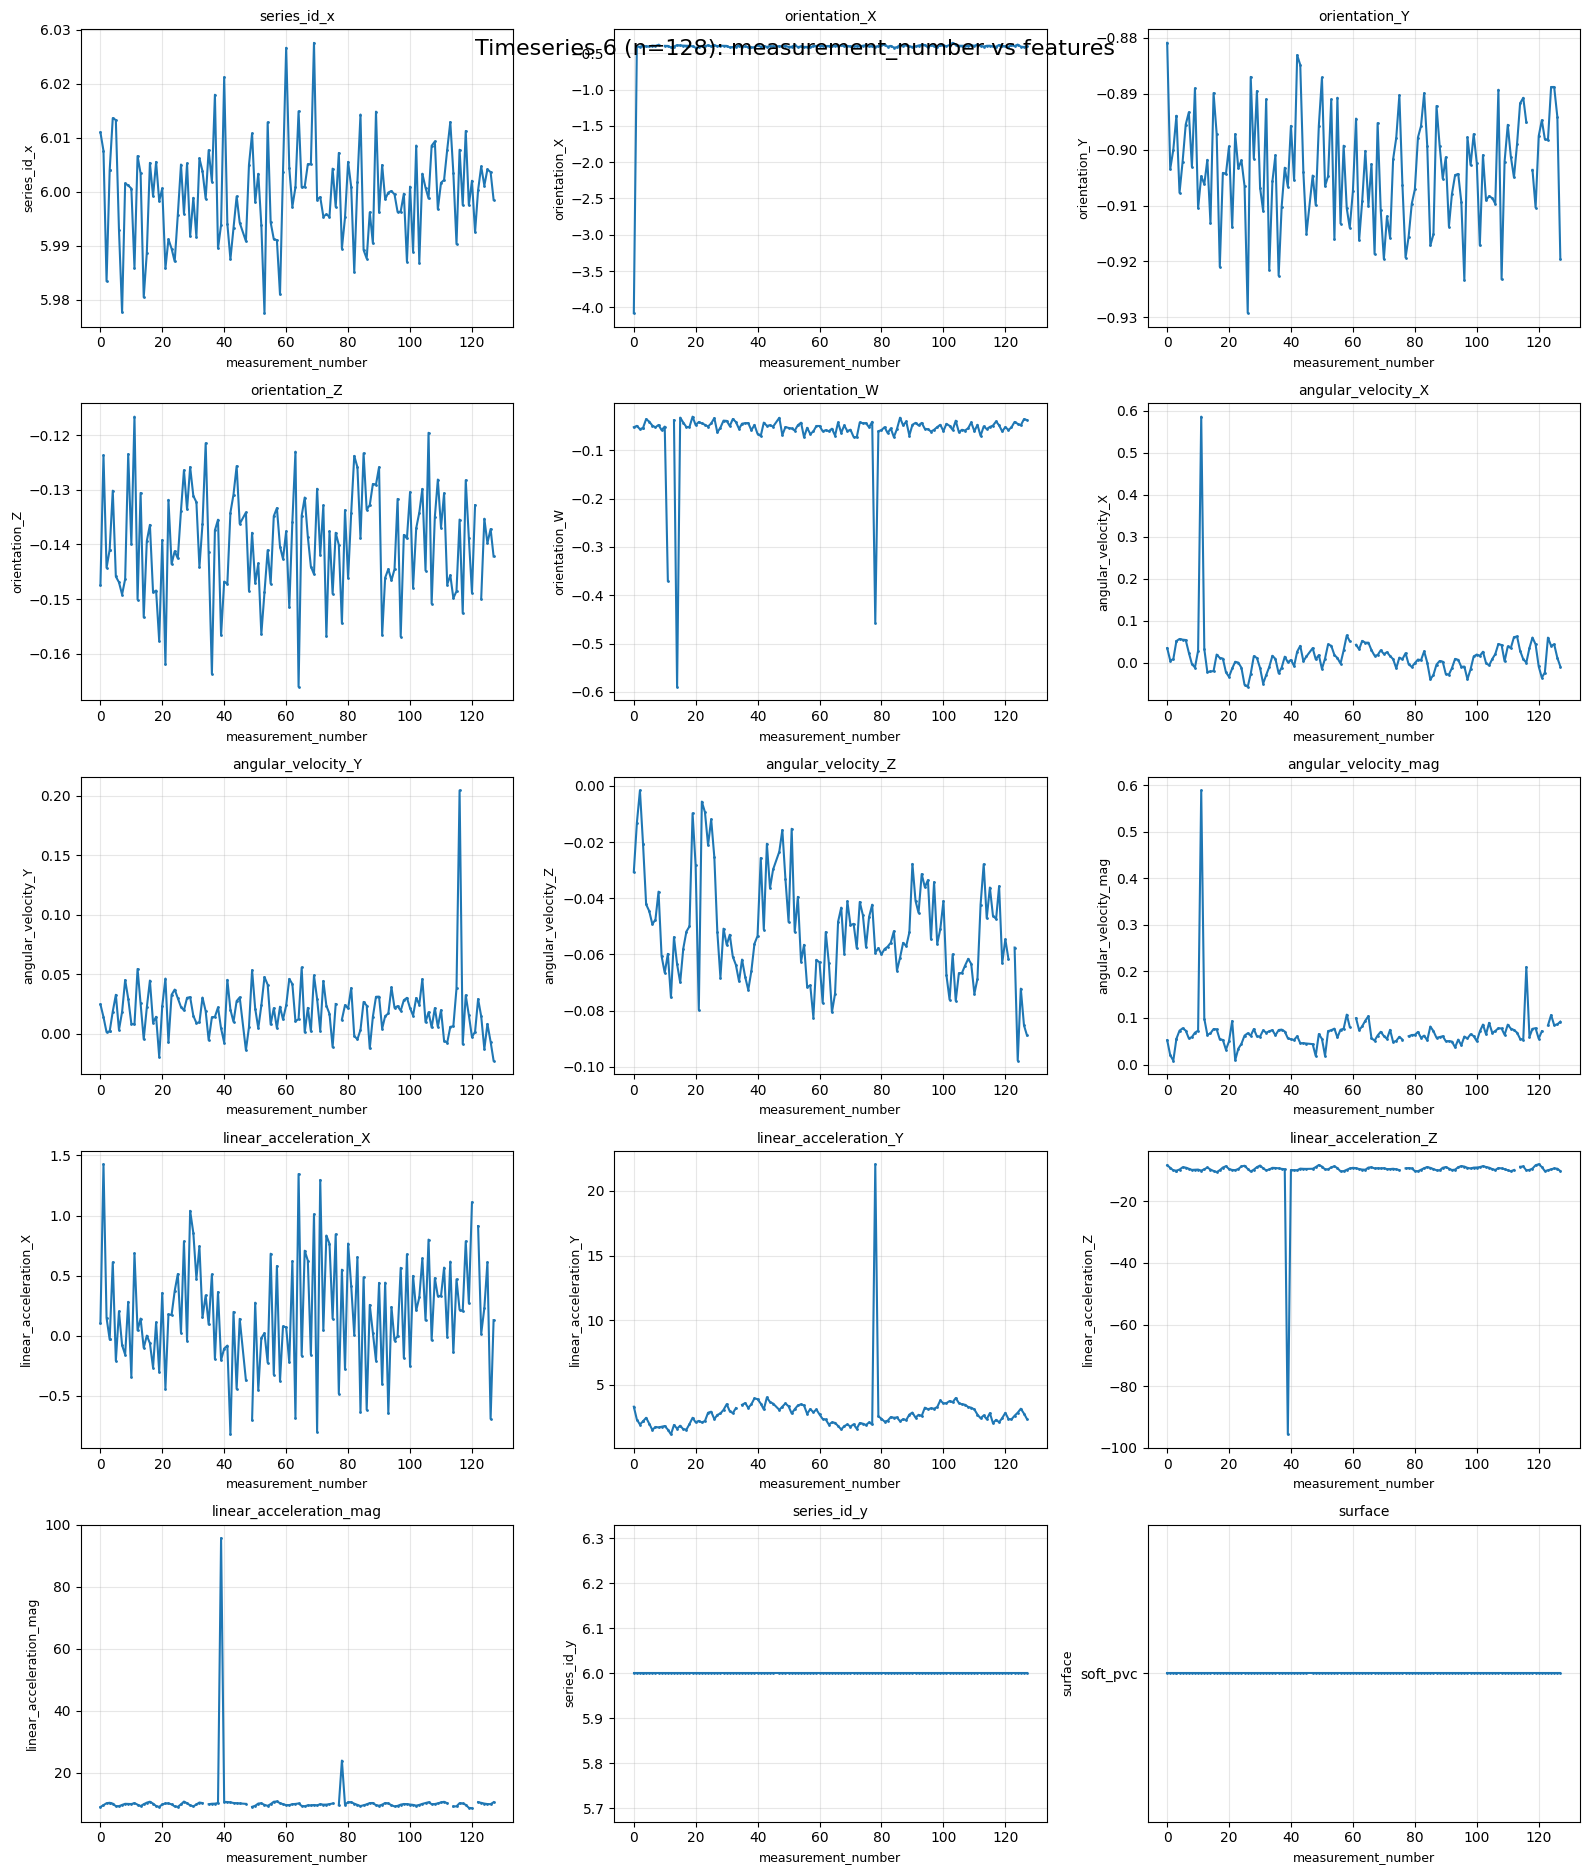

In [73]:
import matplotlib.pyplot as plt

def plot_timeseries_features(df, timeseries_id, registro_col="numerodoregistro",
                             x_col="measurement_number", max_points=128,
                             exclude_cols=None, figsize=(16, 20), ncols=3):
    """
    Plota cada coluna (exceto colunas de controle) para uma timeseries escolhida.
    - df: dataframe organizado (tem columns: row_id, timeseries, numerodoregistro, ...).
    - timeseries_id: valor de df['timeseries'] a plotar.
    - registro_col: eixo X nominal (pode ser numerodoregistro ou measurement_number).
    - x_col: caso queira comparar contra outra variável de posição no sinal.
    - max_points: máximo de pontos para evitar overplot (usa head antes do plot).
    """
    if exclude_cols is None:
        exclude_cols = ["row_id", "timeseries", "numerodoregistro", "series_id", "measurement_number"]

    sub = df[df["timeseries"] == timeseries_id].sort_values(registro_col).reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"Timeseries {timeseries_id} não encontrada")

    if len(sub) > max_points:
        sub = sub.iloc[:max_points]

    feature_cols = [c for c in sub.columns if c not in exclude_cols]
    n_features = len(feature_cols)
    nrows = (n_features + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    fig.suptitle(f"Timeseries {timeseries_id} (n={len(sub)}): {registro_col} vs features", fontsize=16, y=0.92)

    x_values = sub[registro_col]

    for idx, col in enumerate(feature_cols):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r][c]
        ax.plot(x_values, sub[col], marker='.', linestyle='-', markersize=2)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel(registro_col, fontsize=9)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(alpha=0.3)

    # esconder eixos extras
    total_plots = nrows * ncols
    for idx in range(n_features, total_plots):
        r = idx // ncols
        c = idx % ncols
        axes[r][c].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_timeseries_features(dataset_incrementado, timeseries_id=6, registro_col="measurement_number")
# plot_timeseries_features(dataset_organizado, timeseries_id=6, registro_col="numerodoregistro")
# para usar measurement_number no x em vez de numerodoregistro:
# plot_timeseries_features(dataset_organizado, timeseries_id=6, registro_col="measurement_number")

## CNN 1D aprende direto da série temporal — e dispensa extração manual de features

Em abordagens clássicas de machine learning aplicadas a séries temporais (como XGBoost ou Random Forest), é necessária uma etapa de **extração manual de features** antes do treinamento. Essa etapa envolve transformar cada série em um vetor de estatísticas descritivas:

- **Domínio do tempo:** média, desvio padrão, mínimo, máximo, skewness, kurtosis, IQR, energy, zero-crossings, mean_abs_change...
- **Domínio da frequência (FFT):** frequência dominante, energia espectral, média/desvio dos coeficientes...
- **Autocorrelação (ACF):** lags 1, 2, 3, 5, 10, first zero-crossing, número de lags significativos...

Essa engenharia de features exige conhecimento de domínio, é trabalhosa e, principalmente, **introduz uma escolha humana sobre o que é relevante** — ignorando qualquer padrão que o engenheiro não pensou em capturar.

---

### A CNN 1D elimina essa etapa ao aprender os próprios filtros

Uma CNN 1D aplica filtros convolucionais diretamente sobre a sequência bruta de timesteps. Cada filtro é um vetor de pesos aprendido por gradiente, que desliza ao longo do eixo temporal detectando padrões locais. Em termos práticos:

| O que o humano extrairia manualmente | O que a CNN aprende automaticamente |
|---|---|
| Média e desvio padrão da janela | Filtro de suavização com resposta plana |
| Zero-crossings | Filtro diferenciador (detecta mudanças de sinal) |
| Frequência dominante (FFT) | Filtros oscilatórios com diferentes periodicidades |
| Energia do sinal | Filtro quadrático implícito via ativações |
| ACF lag-k | Correlações temporais a distância *k* no campo receptivo |

O ponto-chave é que **a CNN não está limitada a essas métricas pré-definidas**. Ela pode descobrir combinações não-lineares de padrões que nenhuma feature estatística capturaria isoladamente — como uma interação específica entre a vibração no eixo Z e a variação angular no eixo Y que é característica do piso `hard_tiles`.

---

### Pré-processamento mínimo, mas não zero

Mesmo dispensando extração de features, a CNN ainda requer:

1. **Normalização global** (z-score por feature): garante que todos os canais contribuam na mesma escala para os gradientes.
2. **Alinhamento temporal** (padding/truncamento para comprimento fixo): necessário para batches com tensores de forma uniforme.
3. **Imputação de NaNs**: interpolação linear + fill para remover valores ausentes pontuais.

Esses três passos são **agnósticos ao domínio** — não pressupõem nada sobre a física dos sensores — e são executados de forma automática no pipeline.

---

### Quando a CNN supera a extração manual

A CNN tende a superar abordagens de features manuais quando:

- Os padrões discriminativos são **locais e temporais** (dependem da sequência, não só da distribuição dos valores).
- O dataset tem **volume suficiente** para que os filtros convirjam — neste caso ~2.200 séries de treino, que é borderline mas viável com augmentation.
- A **data augmentation** (ruído gaussiano + time shift) é aplicada para ampliar artificialmente a diversidade do treino.

A arquitetura `SimpleCNN` utilizada tem apenas ~100k parâmetros — pequena o suficiente para não sobreajustar em datasets de médio porte, mas expressiva o bastante para capturar padrões temporais relevantes nos 110 timesteps de cada série.


In [74]:
lista_df=[]

for i in dataset_incrementado["timeseries"].unique():
            new = dataset_incrementado[dataset_incrementado["timeseries"] == i]
            novo=new.head(110)
            if new.empty:
                continue
            lista_df.append(novo)



In [75]:
lista_df[0]

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
0,0_0,0,0,-0.010728,0.002334,-0.773039,-0.638283,-0.111479,-0.105607,0.099988,0.018410,0.005460,0.101815,-0.710255,2.099627,-9.746216,9.995079,0.0,fine_concrete
1,0_1,0,1,0.001013,0.990504,-0.750346,-0.630241,-0.096623,-0.102306,0.050083,0.042082,0.004863,0.065597,0.335449,1.487888,-9.406142,9.529001,0.0,fine_concrete
2,0_2,0,2,-0.007640,1.990773,-0.754367,-0.635299,-0.106324,-0.110166,0.001823,0.043896,-0.006134,0.044360,-0.262025,1.587835,-8.725550,8.872716,0.0,fine_concrete
3,0_3,0,3,-0.001271,2.979143,-0.759495,-0.643595,-0.115643,-0.101742,0.002906,-0.007165,-0.015861,0.017646,0.421174,1.088723,-10.113493,10.180641,0.0,fine_concrete
4,0_4,0,4,0.008142,3.998463,-0.751108,-0.647003,-0.120263,-0.126985,0.016671,0.004646,0.005801,0.018253,-5.134896,1.460306,-10.437720,11.723722,0.0,fine_concrete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,0_106,0,106,0.007294,105.986463,-0.748329,-0.617621,-0.116141,-0.084227,0.027969,-0.010814,0.000758,0.029996,0.067185,3.326741,-9.939994,10.482138,0.0,fine_concrete
106,0_107,0,107,-0.000382,106.994649,-0.759613,-0.627318,-0.111432,-0.100471,0.056863,-0.024188,-0.002800,0.061858,0.338357,4.621260,-8.420181,9.610930,0.0,fine_concrete
107,0_108,0,108,-0.011951,108.000659,-0.763963,-0.633173,-0.115283,-0.113987,0.023688,-0.015098,0.000458,0.028094,0.903165,4.715482,-8.025155,9.351716,0.0,fine_concrete
108,0_109,0,109,-0.018530,109.007738,-0.751805,-0.639947,-0.089610,-0.111062,0.015095,-0.068183,0.000664,0.069837,-1.040964,4.280883,-8.002173,9.134787,0.0,fine_concrete


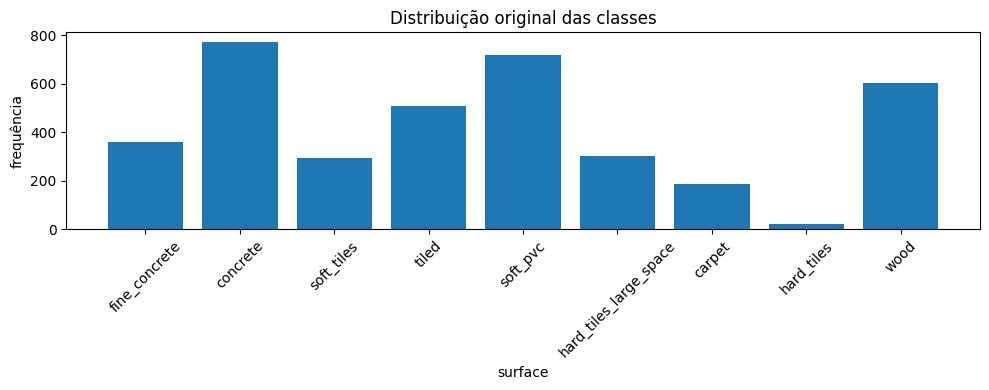

In [76]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def random_split(lista_df, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42):

    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("As proporções devem somar 1.0")

    # classes para histograma
    classes = [df["surface"].iloc[0] for df in lista_df]

    contagem = Counter(classes)

    plt.figure(figsize=(10,4))
    plt.bar(contagem.keys(), contagem.values())
    plt.title("Distribuição original das classes")
    plt.xlabel("surface")
    plt.ylabel("frequência")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # embaralhar lista
    rng = np.random.default_rng(random_state)
    shuffled = lista_df.copy()
    rng.shuffle(shuffled)

    n = len(shuffled)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train = shuffled[:n_train]
    val = shuffled[n_train:n_train + n_val]
    test = shuffled[n_train + n_val:]

    return [train, val, test]

train, val, test = random_split(lista_df)

In [77]:
train[0]

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
426593,3427_0,3427,0,3427.001952,0.017022,-0.932681,-0.317037,-0.058434,-0.149099,-0.004503,0.219592,-0.679031,0.713670,-0.846152,3.449510,-9.859107,10.479364,3427.0,carpet
426594,3427_1,3427,1,3427.002291,0.997249,-0.918719,-0.323607,-0.067828,-0.134988,0.004005,0.229945,-0.665581,0.704194,-0.926563,36.150423,-9.636131,37.424145,3427.0,carpet
426595,3427_2,3427,2,3427.005706,2.001839,-0.931270,-3.273481,-0.059769,-0.139834,0.006825,0.211046,-0.666003,0.698676,-0.630855,3.624145,-9.385755,10.080913,3427.0,carpet
426596,3427_3,3427,3,3427.011876,3.013554,-0.913964,-0.346172,-0.067233,-0.137705,0.010338,0.231781,-0.656489,0.696281,-0.733111,3.805205,-9.045238,9.840395,3427.0,carpet
426597,3427_4,3427,4,3427.019454,3.984229,-0.950110,-0.345217,-0.066971,-1.616569,-0.004262,0.208080,-0.663984,0.695838,-0.505745,3.758563,-9.039999,9.803272,3427.0,carpet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426698,3427_107,3427,107,3427.014560,106.998260,-0.894265,-0.424228,-0.062587,-0.130503,0.013285,0.207981,-0.692203,0.722895,-0.416934,2.303949,-9.299432,9.589654,3427.0,carpet
426699,3427_108,3427,108,3427.021920,107.990930,-0.892238,-0.439058,-0.080487,-0.141551,-0.005331,0.208017,-0.686722,0.717556,-0.555535,2.489053,-9.161865,9.510193,3427.0,carpet
426700,3427_109,3427,109,3427.008729,108.990649,-0.906226,-0.427505,-0.063590,-0.131112,0.005944,0.212245,-0.691849,0.723698,-0.703314,2.624639,-9.114029,9.510463,3427.0,carpet
426701,3427_110,3427,110,3427.004753,109.995148,-0.874877,-0.436173,-0.093507,-0.122376,0.014237,0.222441,-0.677723,0.713436,-0.528789,2.376666,-9.241601,9.556953,3427.0,carpet


### Configuraçao de Arquitetura, treino da CNN e avaliaçao

In [78]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

In [79]:
train_list = train
val_list   = val
test_list  = test

# algumas features nao entram
cols_excluir = {
    "row_id", "timeseries", "numerodoregistro",
    "surface", "series_id_x", "series_id_y",
    "measurement_number"
}

feature_cols = [
    c for c in train_list[0].columns
    if c not in cols_excluir and pd.api.types.is_numeric_dtype(train_list[0][c])
]
print("Features:", feature_cols)
print("Total:", len(feature_cols))

Features: ['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W', 'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z', 'angular_velocity_mag', 'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z', 'linear_acceleration_mag']
Total: 12


In [80]:
# label encoder
y_train_str = [df["surface"].iloc[0] for df in train_list]
y_val_str   = [df["surface"].iloc[0] for df in val_list]
y_test_str  = [df["surface"].iloc[0] for df in test_list]

le = LabelEncoder()
le.fit(y_train_str)
print("Classes:", list(le.classes_))

Classes: ['carpet', 'concrete', 'fine_concrete', 'hard_tiles', 'hard_tiles_large_space', 'soft_pvc', 'soft_tiles', 'tiled', 'wood']


In [ ]:
#prepare_df com zero-padding
# SEQ_LEN = menor serie do dataset (sem padding desnecessario)
SEQ_LEN = min(len(df) for df in train_list + val_list + test_list)
print(f"SEQ_LEN (serie mais curta): {SEQ_LEN}")

def prepare_df(df, feature_cols):
    df = df.copy()
    if "numerodoregistro" in df.columns:
        df = df.sort_values("numerodoregistro")
    elif "measurement_number" in df.columns:
        df = df.sort_values("measurement_number")

    feats = [c for c in feature_cols if c in df.columns]
    df[feats] = df[feats].interpolate(method="linear", limit_direction="both").ffill().bfill().fillna(0.0)

    if len(df) >= SEQ_LEN:
        df = df.iloc[:SEQ_LEN].copy()
    else:
        pad = pd.DataFrame(0.0, index=range(SEQ_LEN - len(df)), columns=df.columns)
        for col in df.columns:
            if col not in feats:
                pad[col] = df.iloc[-1][col]
        df = pd.concat([df, pad], ignore_index=True)

    return df

train_list = [prepare_df(df, feature_cols) for df in train_list]
val_list   = [prepare_df(df, feature_cols) for df in val_list]
test_list  = [prepare_df(df, feature_cols) for df in test_list]

In [82]:
#normalizacao
train_stack = np.concatenate([df[feature_cols].to_numpy(dtype=np.float32) for df in train_list], axis=0)
feat_mean = train_stack.mean(axis=0)
feat_std  = train_stack.std(axis=0) + 1e-8

In [83]:
#classe do Dataset para Pytorch
class TimeSeriesDataset(Dataset):
    def __init__(self, df_list, feature_cols, le, mean, std, augment=False):
        self.df_list      = df_list
        self.feature_cols = feature_cols
        self.le           = le
        self.mean         = mean
        self.std          = std
        self.augment      = augment

    def __len__(self):
        return len(self.df_list)

    def __getitem__(self, idx):
        df = self.df_list[idx]
        x = (df[self.feature_cols].to_numpy(dtype=np.float32) - self.mean) / self.std

        if self.augment:
            if np.random.random() < 0.5:
                x += np.random.normal(0, 0.05, x.shape).astype(np.float32)
            if np.random.random() < 0.3:
                x = np.roll(x, np.random.randint(-8, 8), axis=0)

        x = torch.tensor(x.T, dtype=torch.float32)
        y = torch.tensor(self.le.transform([df["surface"].iloc[0]])[0], dtype=torch.long)
        return x, y

train_ds = TimeSeriesDataset(train_list, feature_cols, le, feat_mean, feat_std, augment=True)
val_ds   = TimeSeriesDataset(val_list,   feature_cols, le, feat_mean, feat_std)
test_ds  = TimeSeriesDataset(test_list,  feature_cols, le, feat_mean, feat_std)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch shape - X:", xb.shape, "| y:", yb.shape)

Batch shape - X: torch.Size([32, 12, 110]) | y: torch.Size([32])


In [84]:
#arquitetura simples
class SimpleCNN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = SimpleCNN(n_channels=len(feature_cols), n_classes=len(le.classes_)).to(device)

with torch.no_grad():
    out = model(xb[:4].to(device))
print("Forward OK - logits shape:", out.shape)
print(f"Parametros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Device: cpu
Forward OK - logits shape: torch.Size([4, 9])
Parametros: 48,073


In [85]:
#loss, optimizer, scheduler
y_train_enc   = le.transform(y_train_str)
class_weights = compute_class_weight("balanced", classes=np.unique(y_train_enc), y=y_train_enc)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6
)

#loop de treino
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_targets = 0.0, [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            logits = model(X)
            loss   = criterion(logits, y)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item() * X.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    n   = len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1  = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    return total_loss / n, acc, f1, np.array(all_targets), np.array(all_preds)

In [86]:
TEST_EVAL_EVERY = 5

n_epochs, patience, patience_counter = 80, 20, 0
best_val_f1, best_state = -np.inf, None
history = {k: [] for k in [
    "train_loss","train_acc","train_f1",
    "val_loss","val_acc","val_f1",
    "test_acc","test_f1"
]}

print("\n=== TREINO ===")
print(f"{'Ep':>4} | {'Tr loss':>8} {'Tr acc':>7} {'Tr f1':>7} | {'Vl loss':>8} {'Vl acc':>7} {'Vl f1':>7} | {'Te acc':>7} {'Te f1':>7} | {'lr':>8}")
print("-" * 100)

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_f1, _, _ = run_epoch(model, val_loader,   criterion)
    scheduler.step(vl_f1)

    if epoch % TEST_EVAL_EVERY == 0 or epoch == 1:
        _, te_acc, te_f1, _, _ = run_epoch(model, test_loader, criterion)
        te_str = f"{te_acc:.4f} {te_f1:.4f}"
    else:
        te_acc, te_f1 = None, None
        te_str = "  -      -  "

    for k, v in zip(
        ["train_loss","train_acc","train_f1","val_loss","val_acc","val_f1","test_acc","test_f1"],
        [tr_loss, tr_acc, tr_f1, vl_loss, vl_acc, vl_f1, te_acc, te_f1]
    ):
        history[k].append(v)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"{epoch:4d} | {tr_loss:8.4f} {tr_acc:7.4f} {tr_f1:7.4f} | "
          f"{vl_loss:8.4f} {vl_acc:7.4f} {vl_f1:7.4f} | {te_str} | {lr_now:.2e}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_state  = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping na epoca {epoch}.")
            break

model.load_state_dict(best_state)
print(f"\nMelhor Val F1: {best_val_f1:.4f}")


=== TREINO ===
  Ep |  Tr loss  Tr acc   Tr f1 |  Vl loss  Vl acc   Vl f1 |  Te acc   Te f1 |       lr
----------------------------------------------------------------------------------------------------
   1 |   1.8962  0.2545  0.2269 |   1.7242  0.4138  0.3508 | 0.3550 0.2977 | 1.00e-03
   2 |   1.6881  0.3719  0.3188 |   1.5528  0.4562  0.3815 |   -      -   | 1.00e-03
   3 |   1.5727  0.3844  0.3453 |   1.5256  0.4602  0.3971 |   -      -   | 1.00e-03
   4 |   1.5192  0.4210  0.3739 |   1.4487  0.4881  0.4517 |   -      -   | 1.00e-03
   5 |   1.4986  0.4371  0.3862 |   1.3666  0.4788  0.4443 | 0.4543 0.4093 | 1.00e-03
   6 |   1.4264  0.4571  0.4138 |   1.3633  0.5371  0.4778 |   -      -   | 1.00e-03
   7 |   1.3902  0.4580  0.4100 |   1.2800  0.5491  0.5090 |   -      -   | 1.00e-03
   8 |   1.3605  0.4750  0.4369 |   1.2809  0.5252  0.5087 |   -      -   | 1.00e-03
   9 |   1.3578  0.4946  0.4506 |   1.2323  0.5305  0.4866 |   -      -   | 1.00e-03
  10 |   1.3173  0.4866  0.4


=== FINAL TEST RESULTS ===
Accuracy: 0.5563
F1 Macro: 0.5240

=== CLASSIFICATION REPORT ===
                        precision    recall  f1-score   support

                carpet       0.41      0.64      0.50        47
              concrete       0.63      0.43      0.51       143
         fine_concrete       0.28      0.24      0.26        66
            hard_tiles       0.22      1.00      0.36         2
hard_tiles_large_space       0.59      0.76      0.66        58
              soft_pvc       0.68      0.63      0.66       158
            soft_tiles       0.58      0.84      0.68        62
                 tiled       0.56      0.60      0.58        96
                  wood       0.56      0.46      0.50       123

              accuracy                           0.56       755
             macro avg       0.50      0.62      0.52       755
          weighted avg       0.57      0.56      0.55       755



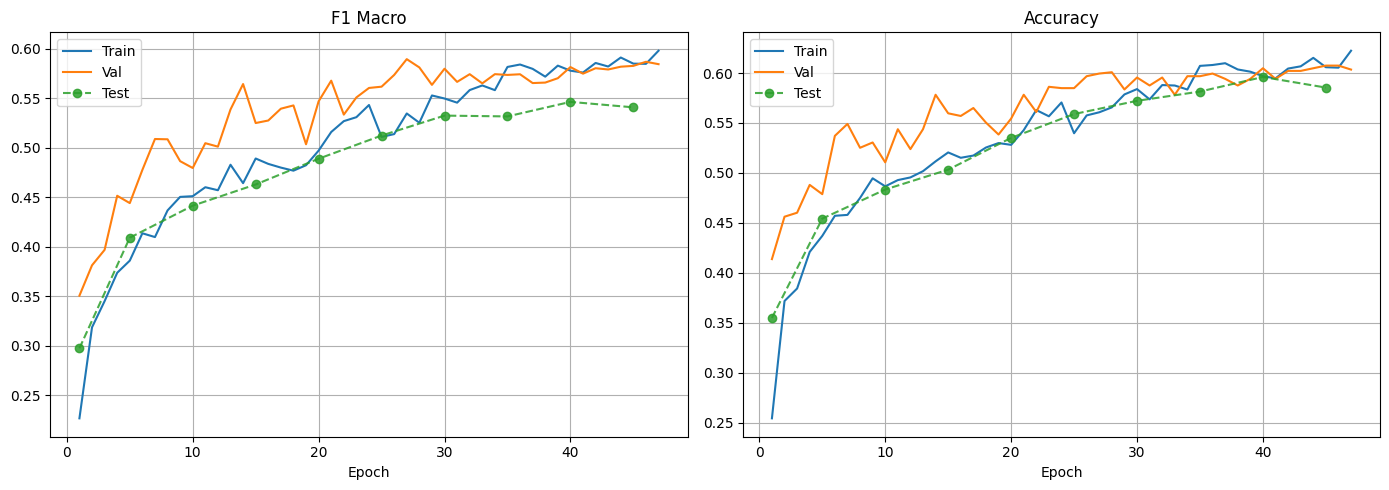

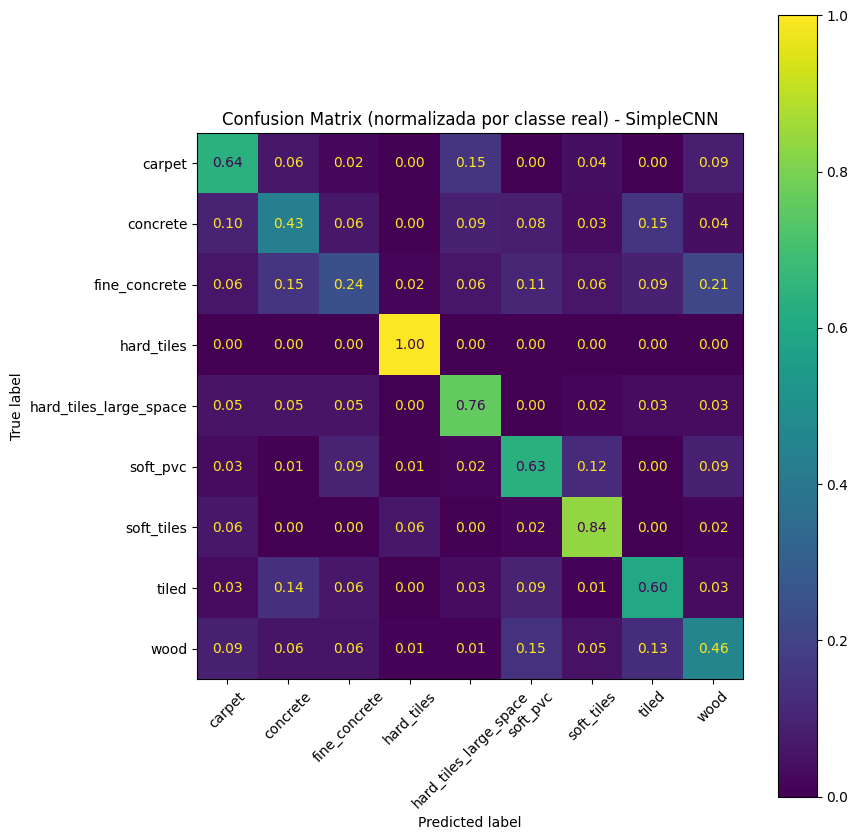

In [87]:
#avaliaçao final
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(model, test_loader, criterion)

print("\n=== FINAL TEST RESULTS ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Macro: {test_f1:.4f}")
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

#curvas de aprendizado
ep_range = range(1, len(history["train_f1"]) + 1)

te_ep   = [i+1 for i, v in enumerate(history["test_f1"])  if v is not None]
te_f1v  = [v   for v in history["test_f1"]  if v is not None]
te_accv = [v   for v in history["test_acc"] if v is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep_range, history["train_f1"], label="Train")
axes[0].plot(ep_range, history["val_f1"],   label="Val")
axes[0].plot(te_ep,    te_f1v, "o--",       label="Test", alpha=0.85)
axes[0].set_title("F1 Macro"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep_range, history["train_acc"], label="Train")
axes[1].plot(ep_range, history["val_acc"],   label="Val")
axes[1].plot(te_ep,    te_accv, "o--",       label="Test", alpha=0.85)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

#Confunsion Matrix normalizada
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, values_format=".2f")
plt.title("Confusion Matrix (normalizada por classe real) - SimpleCNN")
plt.tight_layout()
plt.show()

In [88]:
!pip install torch

In [89]:
dataset_incrementado.head()

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
0,0_0,0,0,-0.010728,0.002334,-0.773039,-0.638283,-0.111479,-0.105607,0.099988,0.018410,0.005460,0.101815,-0.710255,2.099627,-9.746216,9.995079,0.0,fine_concrete
1,0_1,0,1,0.001013,0.990504,-0.750346,-0.630241,-0.096623,-0.102306,0.050083,0.042082,0.004863,0.065597,0.335449,1.487888,-9.406142,9.529001,0.0,fine_concrete
2,0_2,0,2,-0.007640,1.990773,-0.754367,-0.635299,-0.106324,-0.110166,0.001823,0.043896,-0.006134,0.044360,-0.262025,1.587835,-8.725550,8.872716,0.0,fine_concrete
3,0_3,0,3,-0.001271,2.979143,-0.759495,-0.643595,-0.115643,-0.101742,0.002906,-0.007165,-0.015861,0.017646,0.421174,1.088723,-10.113493,10.180641,0.0,fine_concrete
4,0_4,0,4,0.008142,3.998463,-0.751108,-0.647003,-0.120263,-0.126985,0.016671,0.004646,0.005801,0.018253,-5.134896,1.460306,-10.437720,11.723722,0.0,fine_concrete


## Analise de Vies e Variança

Olhando as curvas de aprendizado, o padrão que aparece de cara é que treino, validação e teste andam muito juntos durante todo o processo — o que já diz bastante sobre o tipo de problema que estamos lidando.

Na época 1, o treino tinha F1 de 0.23, a validação 0.35 e o teste 0.30. Ou seja, o modelo performava melhor nos dados que ele nunca tinha visto do que nos dados de treino. Isso é um sinal claro de que ele ainda estava longe de decorar qualquer coisa — estava apenas tentando aprender os padrões mais básicos.

Ao longo do treino essa diferença foi diminuindo, mas o val e o test continuaram próximos ou acima do treino por bastante tempo. Na época 30, por exemplo: treino em 0.55, val em 0.58, teste em 0.53. Na época 40: treino 0.58, val 0.58, teste 0.55. O modelo nunca abriu uma diferença significativa entre treino e os outros conjuntos — o que indica baixa variância, sem overfitting relevante.

O early stopping aconteceu na época 47, com o melhor val F1 em 0.59 (época 27). O resultado final no teste ficou em F1 Macro de 0.52 e acurácia de 0.56 — bem alinhado com o que as curvas mostravam.

O problema aqui não é overfitting. O modelo é estável, mas limitado. Ele convergiu para um platô em torno de 0.58-0.60 e não conseguiu passar disso — nem no treino. Isso é alto viés. A arquitetura provavelmente não tem capacidade suficiente para distinguir bem as 9 superfícies a partir das séries temporais brutas dos sensores, principalmente classes parecidas como `fine_concrete` e `concrete`, que ficaram com F1 abaixo de 0.30 e 0.51 respectivamente.

## Comparação de pelo menos dois algoritmos e justificativa da escolha dos modelos

Neste projeto foram avaliados dois algoritmos para classificação do tipo de superfície com base em sinais temporais de sensores IMU: **XGBoost** e **Rede Neural Convolucional 1D (CNN 1D)**.

---

### 1. Resultados obtidos

| Modelo | Train Accuracy | Train F1 Macro | Val F1 Macro | Test Accuracy | Test F1 Macro |
|--------|---------------|----------------|--------------|---------------|---------------|
| XGBoost (melhor trial) | 1.0000 | 1.0000 | 0.8077 | 0.7868 | **0.7496** |
| CNN 1D (SimpleCNN) | — | — | 0.5897 | 0.5563 | **0.5240** |

O XGBoost superou a CNN 1D em todas as métricas de avaliação. O melhor trial do XGBoost utilizou os seguintes hiperparâmetros: `max_depth=12`, `learning_rate=0.05`, `n_estimators=600`, `subsample=1.0`, `colsample_bytree=0.8`, `reg_alpha=0.01`, `reg_lambda=1.0`, `min_child_weight=1`, `gamma=0.05`.

---

#### XGBoost (Extreme Gradient Boosting)

O XGBoost é um algoritmo de ensemble baseado em boosting que constrói sequencialmente um conjunto de árvores de decisão, cada uma corrigindo os erros da anterior. Incorpora regularização L1 e L2 nativamente, controle de profundidade de árvore e subamostragem de instâncias e features por árvore.

**Particularidades neste projeto:**
- Requer extração prévia de features estatísticas das séries temporais (média, desvio padrão, skewness, kurtosis, FFT, ACF, entre outras), operando sobre dados tabulares.
- Hiperparâmetros otimizados via Optuna com busca bayesiana (25 trials).
- O Train F1 atingiu 1.0 em todos os trials, indicando memorização completa do conjunto de treino — overfitting controlado pela regularização na generalização.

**Vantagens:**
- Elevado desempenho em dados tabulares com features bem construídas.
- Treinamento rápido e interpretável via feature importance.
- Robusto ao desbalanceamento de classes.

**Limitações:**
- Não captura padrões temporais diretamente — depende inteiramente da qualidade da engenharia de features.
- Perde informação de ordem e dinâmica temporal ao agregar em estatísticas.

---

#### CNN 1D (Rede Neural Convolucional Unidimensional)

A CNN 1D opera diretamente sobre a sequência temporal bruta, aprendendo automaticamente filtros convolucionais que detectam padrões locais nos sinais ao longo do eixo do tempo.

**Arquitetura utilizada (SimpleCNN):**
```
Conv1d(12 → 64, kernel=7) → BatchNorm → ReLU → MaxPool1d(2)
Conv1d(64 → 128, kernel=5) → BatchNorm → ReLU → AdaptiveAvgPool1d(1)
Flatten → Dropout(0.4) → Linear(128 → 9 classes)
```

**Particularidades neste projeto:**
- Opera sobre séries temporais brutas, dispensando extração manual de features.
- Utiliza zero-padding para uniformizar comprimento das sequências (110 timesteps).
- Treinado com CrossEntropyLoss ponderada por classe e scheduler `ReduceLROnPlateau`.
- Early stopping ativado na época 47 (patience=20), com melhor Val F1 de 0.5897.

**Vantagens:**
- Aprende representações diretamente dos dados, sem engenharia manual de features.
- Potencialmente mais generalizável para novos padrões temporais.

**Limitações:**
- Arquitetura simples demais para o problema — convergiu com alto viés (Train F1 ≈ Val F1 ≈ Test F1 durante todo o treino).
- Requer mais dados e/ou arquitetura mais profunda para atingir desempenho competitivo.

---

### 3. Justificativa da escolha do XGBoost como modelo principal

Diante dos resultados obtidos, o **XGBoost foi o modelo com melhor desempenho**, atingindo Test F1 Macro de **0.7496** contra **0.5240** da CNN 1D — uma diferença de 22,5 pontos percentuais.

A superioridade do XGBoost neste contexto se explica por dois fatores:

1. **Qualidade da engenharia de features:** o pipeline de extração de features estatísticas (incluindo FFT e ACF) capturou de forma eficaz as características discriminativas das superfícies, compensando a perda da dimensão temporal.

2. **Volume de dados:** com séries temporais de 110 timesteps e um número limitado de séries por classe, o XGBoost converge mais facilmente do que uma rede neural, que requer mais exemplos para aprender representações úteis.

A CNN 1D permanece como alternativa relevante para cenários com maior volume de dados ou com padrões temporais mais ricos que a abordagem tabular não consiga capturar.

---
